In [7]:
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
# 1. Configuration Constants (from Paper/SI)
W_I = 8.3e-4  # Average metabolic weight
W_R = 0.17    # Ribosomal weight
PHI_Q = 0.45  # Housekeeping offset
PHI_R0 = 0.066 # Ribosomal offset
PHI_MAX = 1 - PHI_Q - PHI_R0 # Total allocatable budget (~0.484)

# Reaction IDs for iJO1366
BIOMASS_ID = "BIOMASS_Ec_iJO1366_core_53p95M"
GLC_ID = "EX_glc__D_e"
PFK_ID = "PFK" # EMP Pathway marker
EDD_ID = "EDD" # ED Pathway marker

In [9]:
df_final = pd.read_csv("cafba_sweep_results.csv", index_col=0)

In [10]:
df_final

,w_c,growth_rate,phi_C,phi_E,phi_R,flux_PFK,flux_EDD,flux_glc
0,0.000000,0.742060,0.000000,0.377760,0.192150,0.000000,7.438666,8.797038
1,0.000102,0.740644,0.000896,0.377068,0.191909,0.000000,7.425067,8.780846
2,0.000210,0.739148,0.001842,0.376337,0.191655,0.000000,7.410707,8.763748
3,0.000331,0.737495,0.002874,0.375341,0.191374,0.000000,7.204952,8.694337
4,0.000469,0.735604,0.004071,0.374418,0.191053,0.000000,7.187281,8.672845
...,...,...,...,...,...,...,...,...
95,0.884379,0.037023,0.444996,0.032750,0.072294,0.260749,0.000000,0.503174
96,0.912397,0.035579,0.445925,0.032063,0.072048,0.243841,0.000000,0.488740
97,0.941002,0.034185,0.446828,0.031395,0.071811,0.223783,0.000000,0.474843
98,0.970201,0.032841,0.447698,0.030751,0.071583,0.204453,0.000000,0.461449


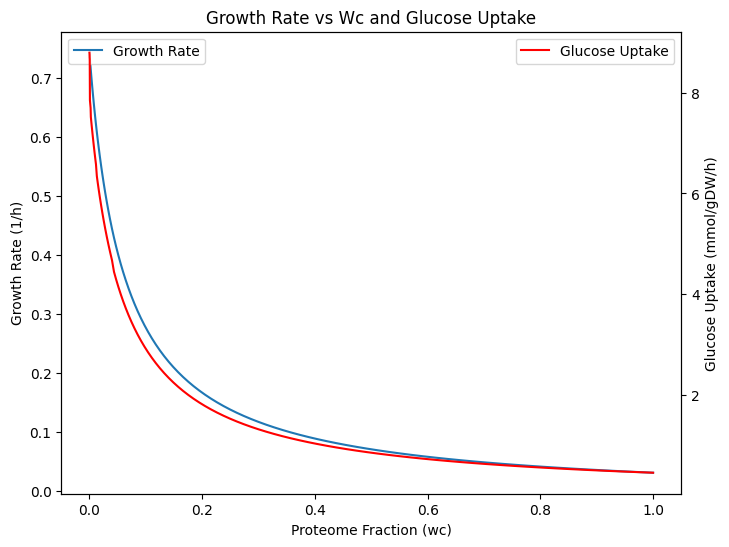

In [18]:
# Plot wc versus growth rate and the glucose uptake flux on the same graph with two y axis (growth rate on left, glucose uptake on right)
plt.figure(figsize=(8, 6))
ax1 = plt.gca()
ax2 = ax1.twinx()

ax1.plot(df_final['w_c'], df_final['growth_rate'], label='Growth Rate')
ax2.plot(df_final['w_c'], df_final['flux_glc'], label='Glucose Uptake', color='red')

ax1.set_xlabel('Proteome Fraction (wc)')
ax1.set_ylabel('Growth Rate (1/h)')
ax2.set_ylabel('Glucose Uptake (mmol/gDW/h)')

# Add legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.title('Growth Rate vs Wc and Glucose Uptake')

# Save the plot
plt.savefig("cafba_wc_growth_rate.png", dpi=300)
plt.show()

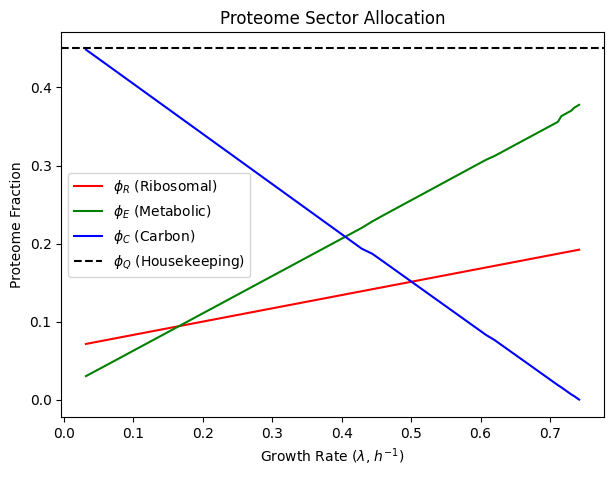

In [11]:
plt.figure(figsize=(7, 5))
plt.plot(df_final['growth_rate'], df_final['phi_R'], color='red', label='$\phi_R$ (Ribosomal)')
plt.plot(df_final['growth_rate'], df_final['phi_E'], color='green', label='$\phi_E$ (Metabolic)')
plt.plot(df_final['growth_rate'], df_final['phi_C'], color='blue', label='$\phi_C$ (Carbon)')
plt.axhline(y=PHI_Q, color='black', linestyle='--', label='$\phi_Q$ (Housekeeping)')
plt.xlabel('Growth Rate ($\lambda$, $h^{-1}$)')
plt.ylabel('Proteome Fraction')
plt.legend()
plt.title('Proteome Sector Allocation')

# Save the plot
plt.savefig("cafba_proteome_allocation.png", dpi=300)
plt.show()

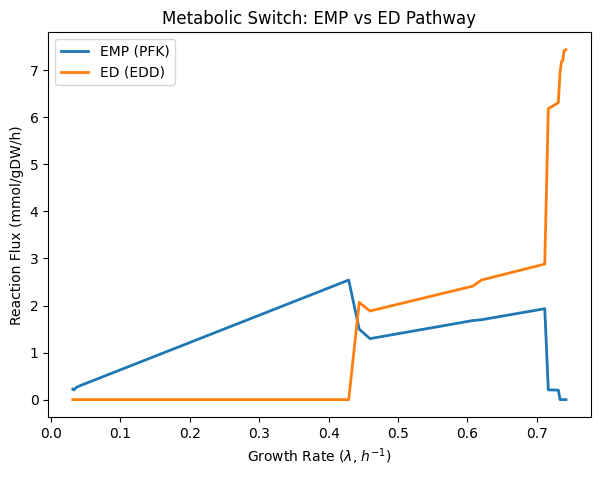

In [12]:
plt.figure(figsize=(7, 5))
plt.plot(df_final['growth_rate'], df_final['flux_PFK'], label='EMP (PFK)', linewidth=2)
plt.plot(df_final['growth_rate'], df_final['flux_EDD'], label='ED (EDD)', linewidth=2)
plt.xlabel('Growth Rate ($\lambda$, $h^{-1}$)')
plt.ylabel('Reaction Flux (mmol/gDW/h)')
plt.title('Metabolic Switch: EMP vs ED Pathway')
plt.legend()

# Save the plot
plt.savefig("cafba_emp_ed_fluxes.png", dpi=300)
plt.show()